In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)
from catboost import CatBoostClassifier

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

In [19]:
base_path = Path("data")

train_path = base_path / "raw" / "train.csv"
test_path = base_path / "raw" / "test.csv"

train_df = pl.read_csv(train_path)
test_df = pl.read_csv(test_path)

In [20]:
X = train_df.drop("Will_Buy_EV", "id")
y = train_df["Will_Buy_EV"]


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)


In [23]:
print(X_train.schema)



Schema({'Age': Int64, 'Annual_Income_USD': Float64, 'Daily_Commute_km': Float64, 'Number_of_Cars_Owned': Int64, 'Charging_Stations_Near_Home': Int64, 'Charging_Stations_Near_Work': Int64, 'Environmental_Concern_Level': Float64, 'Gender': String, 'City_Type': String, 'Current_Car_Type': String, 'Home_Charging_Possible': String, 'Subsidy_Available': String, 'Range_Anxiety_Level': String})


In [24]:
X_train = X_train.to_pandas()
X_val = X_val.to_pandas()
X_test = X_test.to_pandas()

y_train = y_train.to_pandas()
y_val = y_val.to_pandas()
y_test = y_test.to_pandas()

categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print(categorical_features)

['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']


In [25]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    custom_metric=["F1"],
    random_seed=42,
    verbose=100
)


In [26]:
model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=100
)



0:	test: 0.9302188	best: 0.9302188 (0)	total: 140ms	remaining: 2m 19s
100:	test: 0.9391823	best: 0.9391823 (100)	total: 7.09s	remaining: 1m 3s
200:	test: 0.9398933	best: 0.9398933 (200)	total: 13.9s	remaining: 55.4s
300:	test: 0.9402981	best: 0.9402981 (300)	total: 20.8s	remaining: 48.3s
400:	test: 0.9406144	best: 0.9406144 (400)	total: 27.9s	remaining: 41.6s
500:	test: 0.9407744	best: 0.9407744 (500)	total: 34.6s	remaining: 34.5s
600:	test: 0.9408969	best: 0.9408976 (592)	total: 41.6s	remaining: 27.6s
700:	test: 0.9409815	best: 0.9409815 (700)	total: 48.6s	remaining: 20.7s
800:	test: 0.9410544	best: 0.9410547 (794)	total: 55.5s	remaining: 13.8s
900:	test: 0.9410961	best: 0.9410961 (900)	total: 1m 2s	remaining: 6.86s
999:	test: 0.9411292	best: 0.9411307 (995)	total: 1m 9s	remaining: 0us

bestTest = 0.9411307239
bestIteration = 995

Shrink model to first 996 iterations.


CatBoostClassifier(custom_metric=['F1'], depth=6, eval_metric='AUC', iterations=1000, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

Validation ROC AUC: 0.9411
Best threshold:     0.34
Validation F1:      0.7128

              precision    recall  f1-score   support

          No       0.96      0.90      0.93     88302
         Yes       0.64      0.81      0.71     18685

    accuracy                           0.89    106987
   macro avg       0.80      0.85      0.82    106987
weighted avg       0.90      0.89      0.89    106987

Confusion matrix:
[[79781  8521]
 [ 3620 15065]]


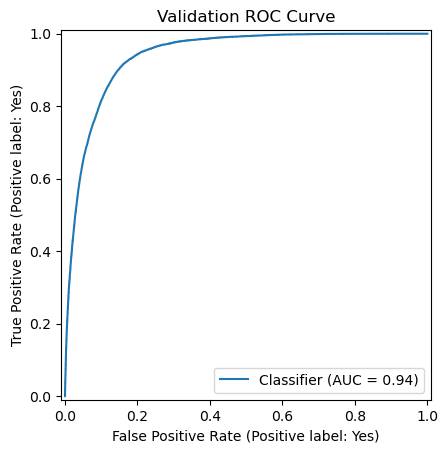

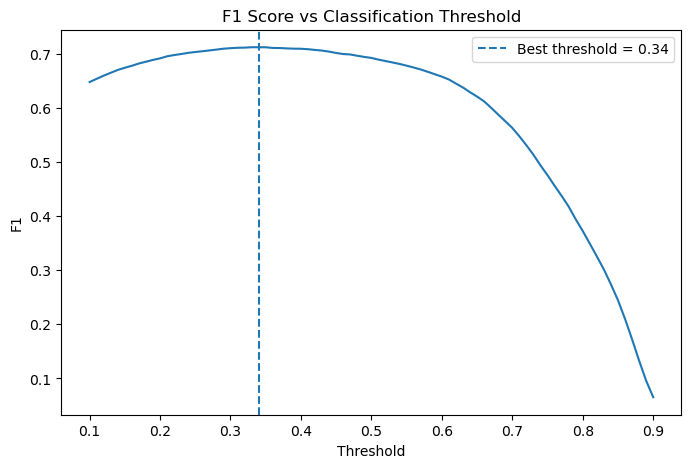

In [27]:
positive_class = "Yes"
positive_class_index = list(model.classes_).index(positive_class)

y_val_proba = model.predict_proba(X_val)[:, positive_class_index]

val_roc_auc = roc_auc_score(
    y_val,
    y_val_proba
)

thresholds = np.arange(0.10, 0.91, 0.01)
f1_scores = []

for threshold in thresholds:
    y_val_pred_threshold = np.where(
        y_val_proba >= threshold,
        "Yes",
        "No"
    )

    score = f1_score(
        y_val,
        y_val_pred_threshold,
        pos_label=positive_class
    )

    f1_scores.append(score)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

y_val_pred = np.where(
    y_val_proba >= best_threshold,
    "Yes",
    "No"
)

print(f"Validation ROC AUC: {val_roc_auc:.4f}")
print(f"Best threshold:     {best_threshold:.2f}")
print(f"Validation F1:      {best_f1:.4f}")

print()
print(classification_report(y_val, y_val_pred))

print("Confusion matrix:")
print(confusion_matrix(y_val, y_val_pred))

RocCurveDisplay.from_predictions(
    y_val,
    y_val_proba,
    pos_label=positive_class
)

plt.title("Validation ROC Curve")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores)
plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title("F1 Score vs Classification Threshold")
plt.legend()
plt.show()


Threshold:    0.34
Test ROC AUC: 0.9414
Test F1:      0.7148

              precision    recall  f1-score   support

          No       0.96      0.90      0.93    110377
         Yes       0.64      0.81      0.71     23356

    accuracy                           0.89    133733
   macro avg       0.80      0.86      0.82    133733
weighted avg       0.90      0.89      0.89    133733

Confusion matrix:
[[99677 10700]
 [ 4415 18941]]


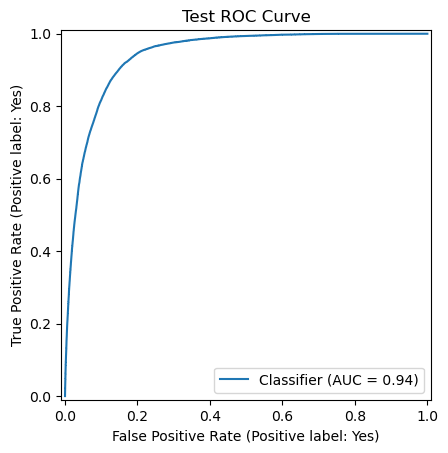

In [28]:
y_test_proba = model.predict_proba(X_test)[:, positive_class_index]

y_test_pred = np.where(
    y_test_proba >= best_threshold,
    "Yes",
    "No"
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    pos_label=positive_class
)

print(f"Threshold:    {best_threshold:.2f}")
print(f"Test ROC AUC: {test_roc_auc:.4f}")
print(f"Test F1:      {test_f1:.4f}")

print()
print(classification_report(y_test, y_test_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba,
    pos_label=positive_class
)

plt.title("Test ROC Curve")
plt.show()
